<a href="https://colab.research.google.com/github/PierreCr/Digital-Pathology/blob/main/Mini_project_in_computational_pathology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-project in Computational Pathology.
# Pierre Cordier, DVM, PhD, Dipl.ECVP.
# 03/10/2026.


In [ ]:
#1. Know your computational environment.
import sys
import platform

print("Python:", sys.version)
print("Platform:", platform.platform())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


# --
#Q1. What Python version is actually running in Colab?
#A1. Python: 3.13.15.

#Q2. Is it the same as Python 3.13.15 on your Mac?
#A2. Python 3.7.1.

#Q3. Why is it useful to record package versions in a computational pathology project?
#A3. In order to be able to reproduce the Python code and the computation.

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.39
NumPy: 2.1.3
pandas: 2.2.3


In [1]:
#2. Install OpenSlide.
!apt-get update
!apt-get install -y openslide-tools
!pip install openslide-python

import openslide
print("OpenSlide:", openslide.__version__)

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:3 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.3 MB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease [17.8 kB]
Get:9 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Packages [61.4 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble/main amd64 Packages [52.1 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:12 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Packages [2,069 kB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd6

In [2]:
#3. Get a small WSI (from Google Drive).
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [3]:
#4. Your first WSI object.
slide = openslide.OpenSlide("/content/drive/MyDrive/WSI_CMU-1/CMU-1.mrxs")

print(slide.dimensions)
print(slide.level_count)
print(slide.level_dimensions)
print(slide.level_downsamples)

for key, value in slide.properties.items():
  print(key, ":", value)


# --
#Q4. What are the dimensions of level 0? How many pixels is that in total?
#A4. Dimensions at level 0: (109240 x 220696). Total pixels: 24,108,831,040 (= 24.1 billion pixels or 24.1 gigapixels).

#Q5. How much larger is that than a normal 224 × 224 CNN input?
#A5. For a tile of (224 x 224), total pixels are 50,176 which is 480,485.3 times smaller.

#Q6. Look at slide.level_dimensions. Why do the dimensions become progressively smaller?
#What do you think the pyramid is used for?
#A6. The dimensions become progressively smaller due to downsampling factor being applied at each level. The pyramid structure is used for visualization at various magnification.

(109240, 220696)
10
((109240, 220696), (54620, 110348), (27310, 55174), (13655, 27587), (6827, 13793), (3413, 6896), (1706, 3448), (853, 1724), (426, 862), (213, 431))
(1.0, 2.0, 4.0, 8.0, 16.0, 32.0, 64.0, 128.0, 256.0, 512.0)
mirax.DATAFILE.FILE_0 : Data0000.dat
mirax.DATAFILE.FILE_1 : Data0001.dat
mirax.DATAFILE.FILE_10 : Data0010.dat
mirax.DATAFILE.FILE_11 : Data0011.dat
mirax.DATAFILE.FILE_12 : Data0012.dat
mirax.DATAFILE.FILE_13 : Data0013.dat
mirax.DATAFILE.FILE_14 : Data0014.dat
mirax.DATAFILE.FILE_15 : Data0015.dat
mirax.DATAFILE.FILE_16 : Data0016.dat
mirax.DATAFILE.FILE_17 : Data0017.dat
mirax.DATAFILE.FILE_18 : Data0018.dat
mirax.DATAFILE.FILE_19 : Data0019.dat
mirax.DATAFILE.FILE_2 : Data0002.dat
mirax.DATAFILE.FILE_20 : Data0020.dat
mirax.DATAFILE.FILE_21 : Data0021.dat
mirax.DATAFILE.FILE_22 : Data0022.dat
mirax.DATAFILE.FILE_3 : Data0003.dat
mirax.DATAFILE.FILE_4 : Data0004.dat
mirax.DATAFILE.FILE_5 : Data0005.dat
mirax.DATAFILE.FILE_6 : Data0006.dat
mirax.DATAFILE.FILE

In [ ]:
#5. Understand the WSI pyramid.

#Q7. Why would you use a low-resolution level to find tissue?
#A7. It decreases computation time and there is no need for high granularity or maximum cell details for that application.

#Q8. Why wouldn't you normally use the lowest-resolution image to perform detailed nuclear classification?
#A8. Nuclear classification requires a high level of nuclear details (size, shape, chromatin aspect...).

#Q9. If level 1 has a downsample of 2 and level 3 has a downsample of 8, what does that mean?
#A9. That means that along each (x,y) axis, there are 2 times and 8 times less pixels for level 1 and level 3, respectively, compared to the level 0 reference.

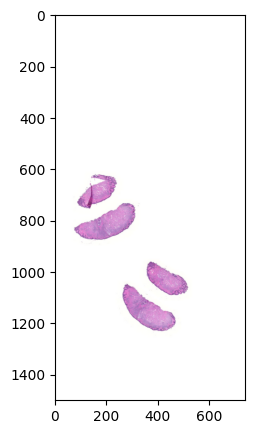

In [ ]:
#6. Make your first thumbnail.
thumbnail = slide.get_thumbnail((1500, 1500))

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(thumbnail)
plt.axis("on");
plt.show()


# --
#Q10. Does the thumbnail preserve the full-resolution image?
#A10. It doesn't, the resolution is reduced to the dimensions indicated in get_thumbnail function (a,b).

#Q11. Why is it useful for tissue detection?
#A11. Tissue detection can be faster and outlines the tissue contours (mostly based on tissue contrast compared to the white background). No need for tissue details.

#Q12. What information is lost?
#A12. Tissue details are lost due to lowest resolution.


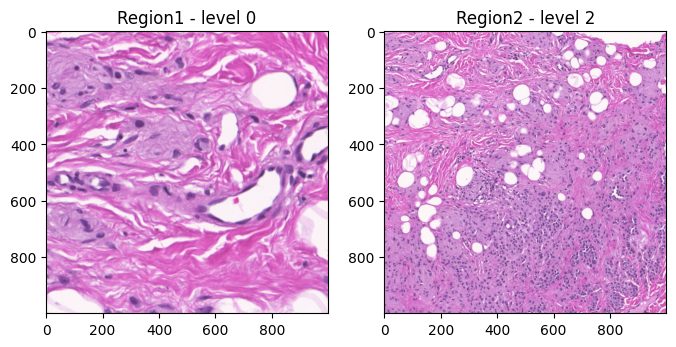

In [ ]:
#7. Understand read_region().
region1 = slide.read_region(
    location=(25000, 100000),
    level=0,
    size=(1000, 1000))

region2 = slide.read_region(
    location=(25000, 100000),
    level=2,
    size=(1000, 1000))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(region1)
plt.title("Region1 - level 0")
plt.axis("on");

plt.subplot(1, 2, 2)
plt.imshow(region2)
plt.title("Region2 - level 2")
plt.axis("on");

plt.show()

# --
#Q13. What is different between the two images?
#A13. The two images are not at the same magnification.

#Q14. Does size=(1000, 1000) mean the same physical area at level 0 and level 2?
#A14. No, it does not: the tissue surface is larger at level 2 for the same tile size of 1000 x 1000.

#Q15. Why is this distinction crucial when extracting pathology patches?
#A15. We need to define a tile size AND a tissue level when extracting pathology patches.

In [ ]:
#8. Understand MPP.
slide.properties

MPP = 0.25
OBJECTIVE = 20

patch_size = 256

physical_size = MPP * patch_size
print(physical_size)


# --
#Q16. At 0.25 μm/pixel, what physical area does a 256 × 256 patch represent?
#A16. It represents a physical area of 64μm x 64μm.

#Q17. At 0.5 μm/pixel?
#A17. Physical area of 128μm x 128μm.

#Q18. Why is saying merely "we used 256 × 256 patches" scientifically incomplete?
#A18. We need to know the MPP (micron per pixel), that is, the resolution.


64.0


(1500, 742, 3)
uint8


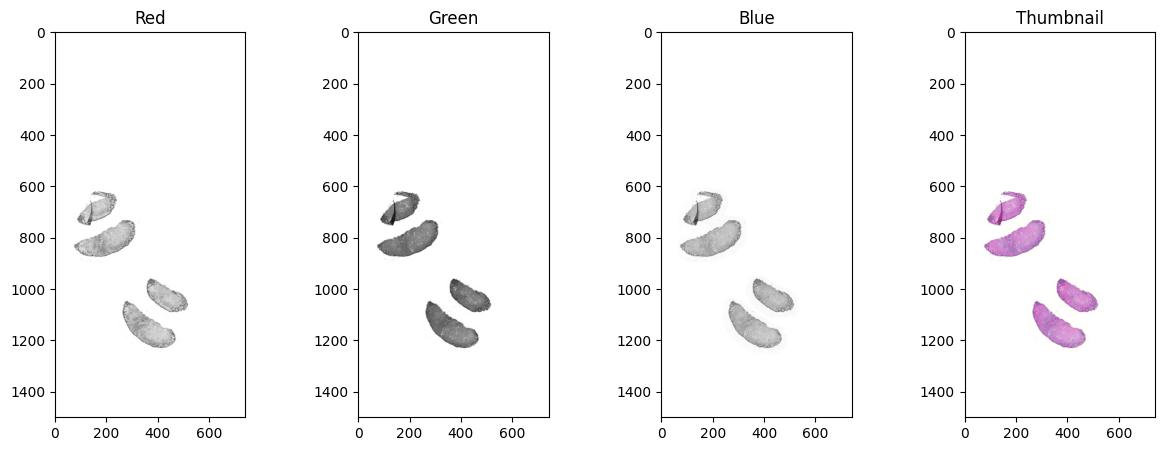

In [ ]:
#9. Build your own thumbnail-based tissue mask.
img = np.array(thumbnail)

print(img.shape)
print(img.dtype)


plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(img[:, :, 0], cmap="gray")
plt.title("Red")
plt.subplot(1, 4, 2)
plt.imshow(img[:, :, 1], cmap="gray")
plt.title("Green")
plt.subplot(1, 4, 3)
plt.imshow(img[:, :, 2], cmap="gray")
plt.title("Blue");
plt.subplot(1, 4, 4)
plt.imshow(thumbnail)
plt.title("Thumbnail");


# --
#Q19. Why might the RGB channels behave differently for H&E?
#A19. The RGB channels decompose each pixel in Red, Green and Blue with intensity values going from 0 (black) to 255 (maximal intensity for the colour).
      #Hematoxylin stains nuclei blue/purple. It tends to contribute strongly to the blue channel, while also affecting red/green to varying degrees.
      #Eosin stains cytoplasm, extracellular matrix, and many proteins pink/red. Its signal is therefore stronger in the red channel, with substantial contribution to green.
      #Consequently, the channels are not independent measurements. A pixel's RGB values are mixtures of the optical effects of both stains plus tissue properties.
      #This is why methods such as optical-density conversion and stain deconvolution are often preferable to treating RGB channels independently.

#Q20. Which channel appears most useful for separating tissue from white background?
#A20. We need to chose the channel with the clearest contrast relative to glass slide white background: Green channel.

##########INFO##########
#Chaque canal (Rouge, Vert, Bleu) est affiché en niveaux de gris pour les raisons suivantes :
  #1. Nature d'un canal unique : Lorsque vous extrayez un canal d'une image couleur (par exemple img[:, :, 0]),
#vous obtenez une matrice à 2 dimensions (hauteur $\times$$\times$ largeur) contenant des valeurs d'intensité comprises entre 0 (noir complet) et 255 (intensité maximale du canal).
#Il n'y a plus d'information tridimensionnelle de couleur (RVB) associée à cette matrice.
  #2. Le paramètre cmap="gray" : Dans votre code, vous passez explicitement l'argument cmap="gray" (pour colormap) à la fonction plt.imshow().
#Cela indique explicitement à Matplotlib de mapper les valeurs d'intensité (de 0 à 255) sur une échelle linéaire allant du noir au blanc.
  #3. Facilité d'analyse visuelle : En pathologie numérique, afficher un canal unique en niveaux de gris permet de mieux visualiser les contrastes de luminance et
#de repérer plus facilement quel canal offre la meilleure séparation entre le tissu (sombre) et le fond en verre de la lame (blanc, proche de 255 sur tous les canaux).

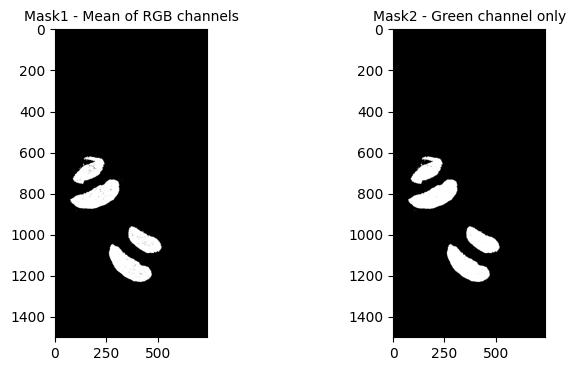

In [ ]:
#10. Simple thresholding.

# Mean of RGB color channels:
gray1 = img.mean(axis=2)
mask1 = gray1 < 220

# Green color channel only:
gray2 = img[:, :, 1]
mask2 = gray2 < 220

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask1 - Mean of RGB channels", fontdict={'size':10});

plt.subplot(1, 2, 2)
plt.imshow(mask2, cmap="gray")
plt.title("Mask2 - Green channel only", fontdict={'size':10});

#Experiment with thresholds 180, 200, 220, and 240.


# --
#Q21. How does changing the threshold affect the mask?
#A21. It modifies the tissue segmentation from the white background.

#Q22. What happens if you choose a threshold that is too low?
#A22. Less/no tissue is recognised: under-segmentation and false negatives (loss of tissue area).

#Q23. What happens if it is too high?
#A23. Non-tissue background is recognised: over-segmentation and false positives (background artifacts included).

##########INFO##########
#Pour la segmentation des tissus sur des images colorées à l'H&E (Hématoxyline et Éosine), il est généralement bien préférable de choisir uniquement
#le canal Vert plutôt que de faire la moyenne des trois canaux. Voici pourquoi :
  #1. Contraste maximal avec le fond : Le fond de la lame (le verre) est blanc, donc très clair (valeurs proches de 255 sur les trois canaux R, G, B).
#Le tissu coloré à l'H&E absorbe fortement la lumière verte (à la fois pour l'hématoxyline bleue/violette et pour l'éosine rose/rouge).
#Le tissu apparaît donc très sombre sur le canal vert, offrant le meilleur contraste possible avec le fond blanc.
  #2. Robustesse de la segmentation : Avec un fort contraste, il est beaucoup plus facile de définir un seuil (threshold) net pour séparer le tissu du fond sans
#inclure de bruit ou exclure du tissu d'intérêt.

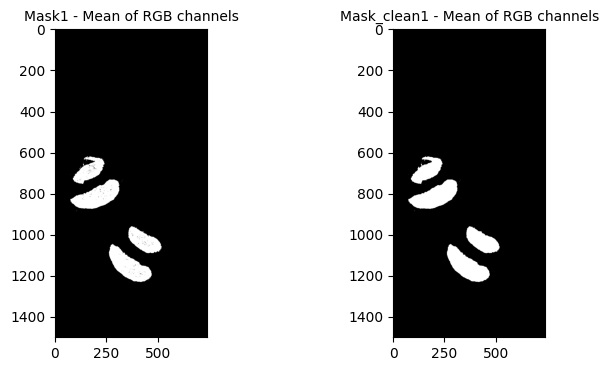

In [ ]:
#11. Improve the mask.
!pip install -q opencv-python
import cv2

kernel = np.ones((5, 5), np.uint8)

mask_clean1 = cv2.morphologyEx(
    mask1.astype(np.uint8),
    cv2.MORPH_CLOSE,
    kernel)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(mask1, cmap="gray")
plt.title("Mask1 - Mean of RGB channels", fontdict={'size':10});

plt.subplot(1, 2, 2)
plt.imshow(mask_clean1, cmap="gray")
plt.title("Mask_clean1 - Mean of RGB channels", fontdict={'size':10});

plt.show()


# --
#Q24. What does morphological closing appear to do?
#A24. It improves tissue segmentation by filling holes and homogenizing the mask.

#Q25. Why might morphological closing be useful for tissue segmentation?
#A25. It improves the quality of segmentation and avoids false positives / negatives.

#Q26. What artifacts could cause a simple thresholding approach to fail?
#Think about pale tissue, empty spaces, folds, pen marks, coverslip artifacts, necrosis, blood, and tissue fragments.
#A26. Most of them + uneven staining of tissue or different stains (other than H&E).

Number of components: 14
[[      0       0     742    1500 1051384]
 [     87     620     153     135   11028]
 [    138     648       1       2       2]
 [     73     708       1       1       1]
 [     74     733     239     143   19229]
 [    326     734       1       2       2]
 [    323     742       1       2       2]
 [    102     882       1       1       1]
 [    104     883       1       1       1]
 [    105     885       1       2       2]
 [    356     961     162     131   12279]
 [    431     978       1       1       1]
 [    261    1047     208     185   19067]
 [    395    1068       1       1       1]]


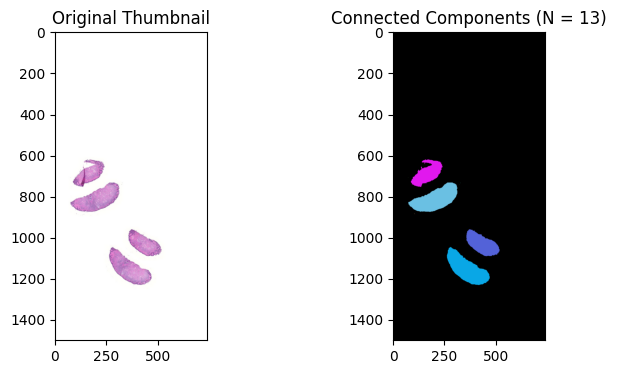

In [ ]:
#12. Connected-Component Analysis (CCA).
import numpy as np
import matplotlib.pyplot as plt

#Connected-component labeling
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    mask_clean1,
    connectivity=8)

print("Number of components:", num_labels)
print(stats)

# Map background to black and other components to a random/distinct color
# We create a random colormap where label 0 (background) remains black
colors = np.random.randint(0, 255, size=(num_labels, 3), dtype=np.uint8)
colors[0] = [0, 0, 0]  # Background is black

# Map each pixel's label to its respective RGB color
colored_labels = colors[labels]

plt.figure(figsize=(8,4))

# Show the original thumbnail for reference
plt.subplot(1, 2, 1)
plt.imshow(thumbnail)
plt.title("Original Thumbnail")
plt.axis("on")

# Show the colored connected components
plt.subplot(1, 2, 2)
plt.imshow(colored_labels)
plt.title(f"Connected Components (N = {num_labels - 1})")
plt.axis("on")

plt.show()


# --
#Q27. Why might removing very small connected components improve your tissue mask?
#A27. It only keeps large and significant tissue sections while removing numeric noises or artifacts.

#Q28. What assumption are you making when you remove small components?
#A28. That those small components are not relevant tissue sections.

#Q29. When could that assumption be wrong?
#Important pathology-AI lesson: Every preprocessing step contains assumptions about biology.
#A29. It could be wrong with fragmented tissue sections, small samples or isolated cells for instance.


`12. Connected-Component Analysis (CCA)`

Ce code utilise la bibliothèque OpenCV (cv2) pour analyser les formes géométriques de votre masque binaire de tissu. Voici une explication détaillée de son fonctionnement et de ses résultats.

1. Que fait ce code ?

La fonction *cv2.connectedComponentsWithStats* effectue un étiquetage des composantes connexes (Connected Component Labeling). Elle regroupe tous les pixels blancs (255) qui se touchent (ici selon une connectivité de 8 directions, c'est-à-dire incluant les diagonales) et leur attribue un numéro unique (un label).

Elle renvoie quatre éléments :

a. **num_labels** : Le nombre total d'objets (composantes) détectés, y compris le fond.

b. **labels** : Une matrice de la même taille que le masque où chaque pixel contient l'identifiant (0 à $N-1$$N-1$) de la composante à laquelle il appartient.

c. **stats** : Une matrice contenant des informations structurelles pour chaque composante :
*   stats[i, cv2.CC_STAT_LEFT] : Coordonnée X de départ (gauche).
*   stats[i, cv2.CC_STAT_TOP] : Coordonnée Y de départ (haut).
*   stats[i, cv2.CC_STAT_WIDTH] : Largeur de la boîte englobante (bounding box).
*   stats[i, cv2.CC_STAT_HEIGHT] : Hauteur de la boîte englobante.
*   stats[i, cv2.CC_STAT_AREA] : La surface totale de la composante en pixels (la colonne la plus à droite).

d. **centroids** : Les coordonnées du centre de gravité $(X, Y)$$(X, Y)$ de chaque composante.

2. Analyse de vos résultats

Votre sortie montre 14 composantes :

La première ligne [0, 0, 742, 1500, 1051384] représente la composante 0, qui correspond toujours au fond (background). Elle couvre l'intégralité de l'image ($742 \times 1500$) et possède la plus grande surface (1 051 384 pixels).
Les autres lignes montrent de véritables objets d'intérêt. Par exemple, la composante 1 possède une surface de 11028 pixels, et la composante 4 possède une surface de 19229 pixels (qui correspondent à vos morceaux de tissu principal).
On remarque également une multitude de micro-composantes de seulement 1 ou 2 pixels (les lignes avec un 1 ou 2 en dernière colonne). Ce sont des poussières ou du bruit numérique.

<class 'tiatoolbox.wsicore.wsireader.base.OpenSlideWSIReader'>


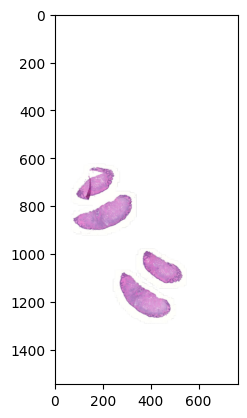

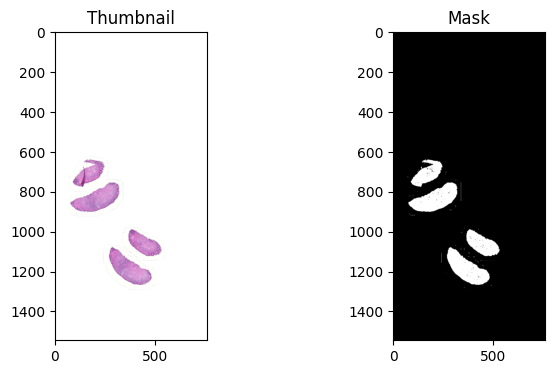

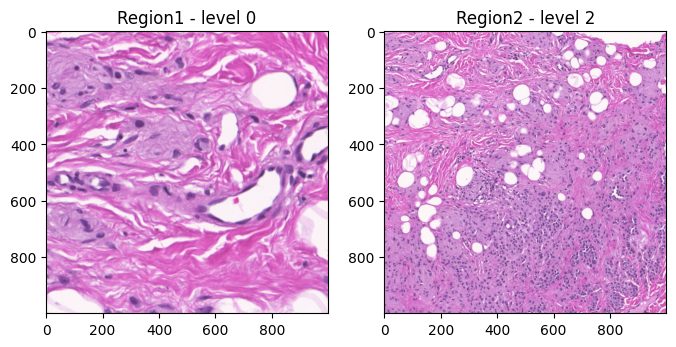

In [ ]:
#13. Compare your implementation with TIAToolbox.
!pip install -q tiatoolbox
from tiatoolbox.wsicore.wsireader import WSIReader
import matplotlib.pyplot as plt

wsi = WSIReader.open("/content/drive/MyDrive/WSI_CMU-1/CMU-1.mrxs")
print(type(wsi))

#Thumbnail generation
thumbnail_tia = wsi.slide_thumbnail(resolution=0.14, units="power")
plt.imshow(thumbnail_tia)
plt.show()

#Tissue masking
mask = wsi.tissue_mask(resolution=0.14, units="power")
mask_thumb = mask.slide_thumbnail(
    resolution=0.14,
    units="power")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(thumbnail_tia)
plt.title("Thumbnail")

plt.subplot(1, 2, 2)
plt.imshow(mask_thumb, cmap="gray")
plt.title("Mask")
plt.show()

#Patch extraction
img_tia1 = wsi.read_rect(
    (25000, 100000),
    (1000,1000),
    resolution=0,
    units="level")

img_tia2 = wsi.read_rect(
    (25000, 100000),
    (1000,1000),
    resolution=2,
    units="level")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_tia1)
plt.title("Region1 - level 0")
plt.axis("on");

plt.subplot(1, 2, 2)
plt.imshow(img_tia2)
plt.title("Region2 - level 2")
plt.axis("on");
plt.show()


# --
#Q30. What did TIAToolbox automate that you previously implemented yourself?
#A30. Tissue masking is easier with TIAToolbox and you can even specify the working resolution. Tissue masking is performed at a WSI scale.
#Thumbnail generation and patch extraction (1 patch) are equivalent to the direct use of OpenSlide.

#Q31. What advantages does a toolbox provide?
#A31. It encompasses within a single Python package many tools required for WSI visualization, transformation and analysis.

#Q32. What disadvantages might there be if you use a high-level function without understanding what it does?
#A32. It can be difficult to truly understand what is behind the code, to debug or modify the pipeline and to adapt it to another project.

In [ ]:
#14. Extract a patch manually.
x = 20316
y = 95340

patch = slide.read_region(
(x, y),
0,
(512, 512))

patch.save("patch_test.png")

In [18]:
#15. Build a patch extraction loop.
import numpy as np

#PARAMETERS#
patch_size = 512

# Get slide dimensions at level 0
slide_w, slide_h = slide.dimensions

# Get thumbnail dimensions to compute scaling factors
thumbnail = slide.get_thumbnail((1500, 1500))
thumb_w, thumb_h = thumbnail.size
scale_x = thumb_w / slide_w
scale_y = thumb_h / slide_h

# We will step through the grid with stride = patch_size
# To avoid extracting thousands of background patches, let's look at the tissue mask
img = np.array(thumbnail)
gray = img[:, :, 1]
mask = gray < 220

#ESTIMATING NUMBER OF EXTRACTED PATCHES#
total_grid_patches = 0
saved_patches_count = 0
patches = []

for y in range(0, int(640/scale_y+1), patch_size):
    for x in range(0, slide_w, patch_size):
        total_grid_patches += 1
        mask_x1 = int(x * scale_x)
        mask_y1 = int(y * scale_y)
        mask_x2 = int((x + patch_size) * scale_x)
        mask_y2 = int((y + patch_size) * scale_y)

        mask_patch = mask[mask_y1:mask_y2, mask_x1:mask_x2]

        if mask_patch.size > 0:
            tissue_proportion = np.mean(mask_patch)
        else:
            tissue_proportion = 0.0

        if tissue_proportion > 0.5:
            saved_patches_count += 1
            patches.append({
              "patch_id": f"CMU-1_patch_{saved_patches_count}",
              "x": x,
              "y": y,
              "width": patch_size,
              "height": patch_size,
              "level": 0,
              "tissue_fraction": f"{tissue_proportion:.1%}"})

print(f"Total grid positions evaluated: {total_grid_patches}")
print(f"Estimated patches to be extracted (tissue proportion > 50%): {saved_patches_count}")


#EXTRACTING PATCHES#
saved_patches_count = 0
for y in range(0, int(640/scale_y+1), patch_size):
    for x in range(0, slide_w, patch_size):
        # Map slide coordinates to mask coordinates
        mask_x1 = int(x * scale_x)
        mask_y1 = int(y * scale_y)
        mask_x2 = int((x + patch_size) * scale_x)
        mask_y2 = int((y + patch_size) * scale_y)

        # Extract the corresponding patch area from our mask
        mask_patch = mask[mask_y1:mask_y2, mask_x1:mask_x2]

        if mask_patch.size > 0:
            # Calculate tissue proportion
            tissue_proportion = np.mean(mask_patch)
        else:
            tissue_proportion = 0.0

        # Save patch only if it contains sufficient tissue (e.g. > 50%)
        if tissue_proportion > 0.5:
            saved_patches_count += 1
            patch_i = slide.read_region((x, y), 0, (patch_size, patch_size))
            patch_i.convert("RGB").save(f"/content/drive/MyDrive/WSI_CMU-1/patches512x512/CMU-1_patch_{saved_patches_count}.png")
            print(f"Saved: CMU-1_patch_{saved_patches_count}.png (Tissue Proportion: {tissue_proportion:.1%})")


# --
#Q33. Why can't you simply use mask[y, x] to decide whether WSI coordinate (x, y) contains tissue?
#A33. Tissue mask is defined at the thumbnail level whereas patches are extracted at the 0 reference level.
#Therefore, coordinates are not directly interchangeable.

#Q34. How would you convert between thumbnail coordinates and level-0 coordinates?
#A34. By calculating a scaling factor for each axis (x, y) or by defining tissue mask at level-0 coordinates.

#Q35. Why is it safer to use the actual WSI dimensions and thumbnail dimensions rather than assuming a fixed scale?
#A35. Both dimensions can vary according to the slide or project.

Saved: CMU-1_patch_1.png (Tissue Proportion: 55.6%)
Saved: CMU-1_patch_2.png (Tissue Proportion: 55.6%)
Saved: CMU-1_patch_3.png (Tissue Proportion: 91.7%)
Saved: CMU-1_patch_4.png (Tissue Proportion: 91.7%)
Saved: CMU-1_patch_5.png (Tissue Proportion: 68.8%)
Saved: CMU-1_patch_6.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_7.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_8.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_9.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_10.png (Tissue Proportion: 75.0%)
Saved: CMU-1_patch_11.png (Tissue Proportion: 66.7%)
Saved: CMU-1_patch_12.png (Tissue Proportion: 56.2%)
Saved: CMU-1_patch_13.png (Tissue Proportion: 58.3%)
Saved: CMU-1_patch_14.png (Tissue Proportion: 88.9%)
Saved: CMU-1_patch_15.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_16.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_17.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_18.png (Tissue Proportion: 100.0%)
Saved: CMU-1_patch_19.png (Tissue Proportion: 1

`15. Build a patch extraction loop.`

1. A counter of the total amount of patches to be extracted is useful.

2. Along y axis, ymax is set at *int(640/scale_y+1)* so that not too many patches are extracted (around 100 vs 5000). This value is based on the bounding box height obtained through connected component analysis in exercise (12).

3. The .convert("RGB") call is used because of how OpenSlide reads slide regions. When you use slide.read_region(...) in OpenSlide, it returns a PIL (Pillow) image in RGBA format (Red, Green, Blue, Alpha/transparency), even if the underlying digital slide has no transparency channel.

In [17]:
#16. Build a patch metadata table.
import pandas as pd

#The code to create the patch metadata table is written in the previous section (under 'estimating number of extracted patches').

df = pd.DataFrame(patches)
df.to_csv("/content/drive/MyDrive/WSI_CMU-1/CMU-1_patches.csv", index=False)

print(df)


# --
#Q36. Why is the coordinate information just as important as the patch image?
#A36. The coordinate information locates the patch image on the WSI.

#Q37. If you lose the coordinates, what becomes difficult or impossible later?
#A37. We may lose spatial information and contextualization of the image patch is no longer possible.

          patch_id      x      y  width  height  level tissue_fraction
0    CMU-1_patch_1  23040  91136    512     512      0           55.6%
1    CMU-1_patch_2  25088  91136    512     512      0           55.6%
2    CMU-1_patch_3  22528  91648    512     512      0           91.7%
3    CMU-1_patch_4  23040  91648    512     512      0           91.7%
4    CMU-1_patch_5  23552  91648    512     512      0           68.8%
..             ...    ...    ...    ...     ...    ...             ...
91  CMU-1_patch_92  31744  93696    512     512      0          100.0%
92  CMU-1_patch_93  32256  93696    512     512      0          100.0%
93  CMU-1_patch_94  32768  93696    512     512      0          100.0%
94  CMU-1_patch_95  33280  93696    512     512      0          100.0%
95  CMU-1_patch_96  33792  93696    512     512      0           87.5%

[96 rows x 7 columns]


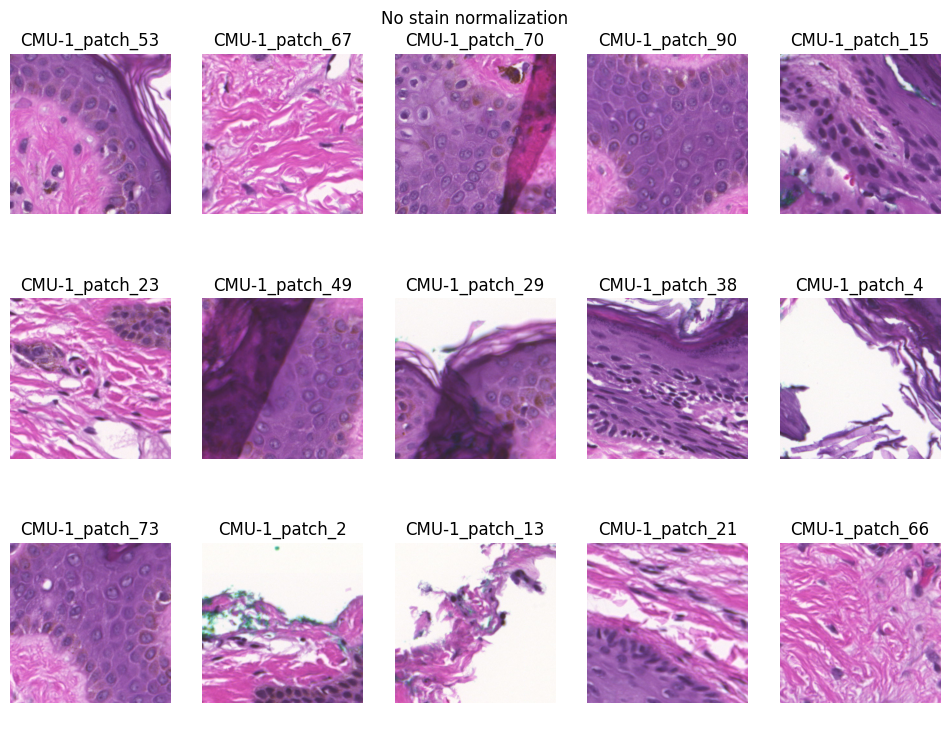

In [79]:
#17. Make a patch gallery.
import matplotlib.pyplot as plt
import random

random.seed(44)
grid = random.sample(df.patch_id.tolist(), k=15)

plt.figure(figsize=(12,9))
plt.title("No stain normalization")
plt.axis("off")
for img in grid:
  plt.subplot(3, 5, grid.index(img)+1)
  plt.imshow(plt.imread(f"/content/drive/MyDrive/WSI_CMU-1/patches512x512/{img}.png"))
  plt.title(f"{img}")
  plt.axis("off")
plt.show()


# --
#Q38. How many patches would you reject?
#A38. 15 patches are shown. 6 patches would be rejected.

#Q39. Why?
#A39. Due to tissue artifacts (folds) or uninformative tissue edges.

#Q40. Could a machine-learning model learn something undesirable from the rejected patches if you included them?
#A40. False prediction or poorer performance.

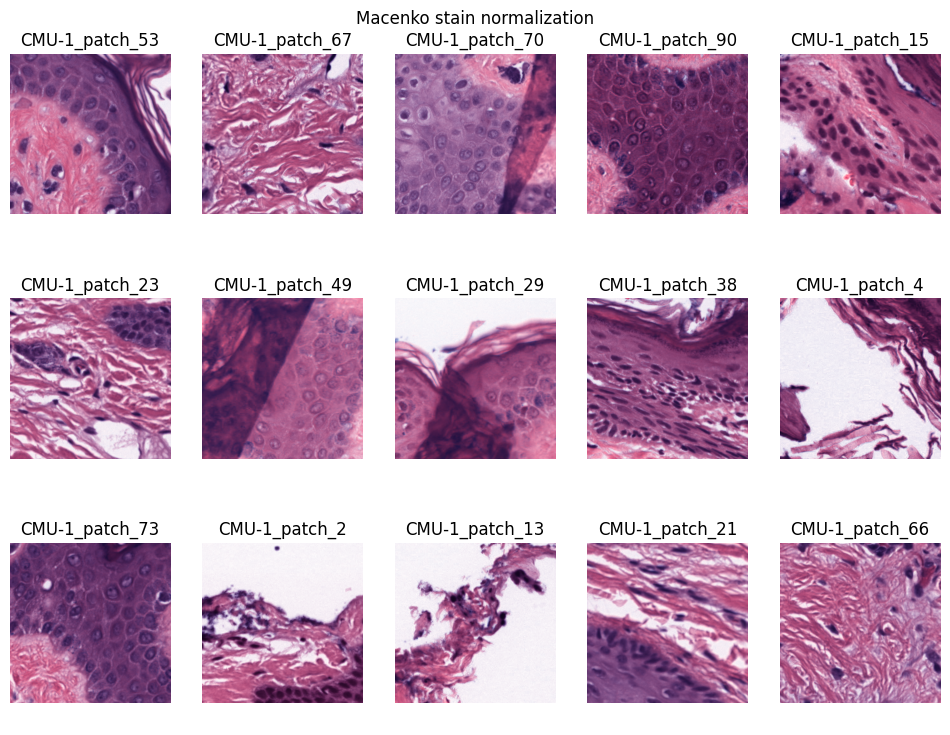

In [115]:
#18. Introduce stain normalization.
!pip install -q tiatoolbox

import numpy as np
from tiatoolbox import data, logger
from tiatoolbox.tools import stainnorm

# Normalizer initialization
target_image = data.stain_norm_target()

stain_normalizer = stainnorm.MacenkoNormalizer()
stain_normalizer.fit(target_image)

# Macenko normalization on .png files
for patch in df.patch_id:
  img = (plt.imread(f"/content/drive/MyDrive/WSI_CMU-1/patches512x512/{patch}.png")*255).astype(np.uint8)
  img_norm = stain_normalizer.transform(img)
  plt.imsave(f"/content/drive/MyDrive/WSI_CMU-1/normedMacenko_patches512x512/{patch}_normed.png", img_norm)
  print(f"Saved: {patch}_normed.png")

# Gallery of Macenko normalized patches
plt.figure(figsize=(12,9))
plt.title("Macenko stain normalization")
plt.axis("off")
for img in grid:
  plt.subplot(3, 5, grid.index(img)+1)
  plt.imshow(plt.imread(f"/content/drive/MyDrive/WSI_CMU-1/normedMacenko_patches512x512/{img}_normed.png"))
  plt.title(f"{img}")
  plt.axis("off")

plt.show()


# --
#Q41. What visual changes do you observe?
#A41. Normalized images appear closer to the target image.

#Q42. Why might stain normalization improve model robustness?
#A42. It reduces staining variability and batch effects, especially for projects working with slides obtained
#from different sites and with different staining protocols.

#Q43. Could normalization ever remove useful biological information?
#A43. Probably. There is only one target image to calculate color vectors (risk of under-representation).
#What would happen if an element not present on the target image is observed on patches to normalized?
#e.g. mineralization, hemosiderin, bilirubin, other pigments, foreign bodies, infectious agents...

#Q44. Why might a normalization method behave differently on veterinary tissue than on the human tissue it was developed/tested on?
#A44. Biological reasons (staining affinity, tissue constituant density and proportions) and
#technical reasons (fixation, tissu preparation, tissue sectioning, section thickness).

`18. Introduce stain normalization`

La fonction plt.imread() génère un tableau NumPy. Cependant, il y a deux pièges très importants avec les fichiers .png et plt.imread() qui expliquent pourquoi la normalisation de Macenko peut échouer ou se comporter bizarrement avec ces images :

1. Le type et la plage de valeurs (Float 0.0 à 1.0 vs Entier 0 à 255)

Pour les fichiers JPEG, plt.imread retourne un tableau d'entiers (uint8) compris entre 0 et 255.
Pour les fichiers PNG, plt.imread normalise automatiquement les valeurs et retourne un tableau de nombres décimaux (float32) compris entre 0.0 et 1.0. Le normaliseur de TIAToolbox s'attend généralement à recevoir des images avec des valeurs entières de 0 à 255 (format standard uint8). Passer des valeurs entre 0.0 et 1.0 fausse complètement les calculs mathématiques de densité optique (OD). Pour régler cela, il faut multiplier par 255 et convertir en uint8 : (img * 255).astype(np.uint8).

2. Le nombre de canaux (RGB vs RGBA)

Si les patchs PNG ont été enregistrés avec un canal de transparence (Alpha), plt.imread va charger un tableau à 4 canaux (RGBA, de dimension [512, 512, 4]). Or, la normalisation de Macenko requiert strictement 3 canaux (RGB, de dimension [512, 512, 3]).

> Why might a normalization method behave differently on veterinary tissue than on the human tissue it was developed/tested on?

Il existe plusieurs raisons biologiques et techniques pour lesquelles une méthode de normalisation de coloration (comme Macenko) se comporte différemment sur les tissus vétérinaires par rapport aux tissus humains sur lesquels elle a été développée et testée :

1. Différences biologiques et composition des tissus

Proportions et densité des constituants : Les ratios de collagène (tissu conjonctif), de lipides (tissu adipeux) et de structures cellulaires varient grandement d'une espèce à l'autre. Par exemple, la peau de certains mammifères domestiques a un derme beaucoup plus dense ou des couches de kératine plus épaisses que l'humain.
Affinité tinctoriale (Staining affinity) : Les protéines et les composants cellulaires des différentes espèces animales ne réagissent pas toujours de la même manière aux colorants (Hématoxyline et Éosine). L'intensité de la fixation et la charge électrique des protéines animales peuvent modifier la quantité de colorant absorbée.

2. Facteurs techniques de laboratoire

Protocoles de fixation et de traitement : En médecine vétérinaire, les délais de fixation, l'épaisseur des prélèvements et la qualité des réactifs sont parfois moins standardisés qu'en pathologie humaine hospitalière. De plus, la qualité du tissu post-mortem (autolyse chez les animaux de rente ou de laboratoire) modifie l'affinité du tissu pour les colorants.
Épaisseur des coupes : Les coupes histologiques vétérinaires sont parfois réalisées à des épaisseurs différentes (ex. 4 à 6 µm) de celles de la pathologie humaine conventionnelle (souvent stricte à 3 ou 4 µm), ce qui modifie la densité optique (OD) mesurée par l'algorithme.

3. Limites inhérentes à l'algorithme de Macenko

Calcul des vecteurs de coloration : La méthode de Macenko repose sur la projection des intensités de pixels dans un espace de densité optique tridimensionnel pour y détecter des extremums (les centiles d'absorption de l'Hématoxyline et de l'Éosine). Si l'échantillon animal présente une coloration de fond inhabituelle, ou s'il y a des pigments spécifiques absents chez l'humain (mélanine abondante, pigments biliaires ou de dégradation comme l'hémosidérine), l'algorithme va mal estimer les vecteurs de référence.
Inadéquation de l'image cible (Target Image) : L'image cible par défaut de TIAToolbox (data.stain_norm_target()) est humaine. Appliquer ses vecteurs à une lame d'oiseau (dont les globules rouges sont nucléés, modifiant drastiquement le ratio Hématoxyline/Éosine dans les vaisseaux) ou de reptile mènera à une distorsion des couleurs.

In [ ]:
#19. Now introduce AI.